# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET

## 2. Data importation

In [3]:
df_merged = pd.read_csv('df_merged.csv')

## 3. Data exploration and understanding

In [3]:
df_merged.tail()

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
4232,42,SSI,SSI070,SSI07098,SSI07098,0,0,0.1,303.37,18270.36,...,273.687,27720.71,872.5,2389.0,-1.2,-0.6,2.4,5.00,6700.0,2024-09-01
4233,15,SSI,SSI070,SSI07099,SSI07099,15584,15584,1.0,323.41,18201.70,...,262.615,23681.17,851.7,2301.1,3.2,-0.1,9.1,1.75,6900.0,2022-06-01
4234,18,SSI,SSI070,SSI07099,SSI07099,110210,110210,0.6,318.24,18201.70,...,262.473,23681.17,813.5,2302.4,4.6,0.4,8.2,3.25,6600.0,2022-09-01
4235,21,SSI,SSI070,SSI07099,SSI07099,273671,273671,0.7,296.90,18316.77,...,253.508,26006.89,806.3,2274.6,-0.8,-1.2,6.5,4.50,6500.0,2022-12-01
4236,24,SSI,SSI070,SSI07099,SSI07099,472923,472923,0.7,302.45,18316.77,...,259.541,26006.89,810.8,2224.4,-0.4,0.4,5.0,5.00,6700.0,2023-03-01


In [4]:
#overview the dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 82 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   int64  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   int64  
 6   Revenue                                   4237 non-null   int64  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [4]:
# get all combinations of subsegments and periods that should exist
all_periods     = pd.DataFrame({'Period': range(1, 43)})
all_subsegments = df_merged[['Business_Unit', 'Segment', 'Subsegment']].drop_duplicates()

# cross join to get every possible combination
full_grid = all_subsegments.assign(key=1).merge(all_periods.assign(key=1), on='key').drop('key', axis=1)

# merge with actual data to find missing combinations
df_merged = full_grid.merge(df_merged, on=['Period', 'Business_Unit', 'Segment', 'Subsegment'], how='left')

# fill revenue and orders with 0 where missing
df_merged['Revenue'] = df_merged['Revenue'].fillna(0)
df_merged['Orders']  = df_merged['Orders'].fillna(0)

# track start period per subsegment (first period where it actually appeared in original data)
start_periods = (
    df_merged[df_merged['Revenue'] != 0]
    .groupby('Subsegment')['Period']
    .min()
    .reset_index()
    .rename(columns={'Period': 'Start_Period'})
)
df_merged = df_merged.merge(start_periods, on='Subsegment', how='left')

print(df_merged.shape)
print(df_merged[['Period', 'Subsegment', 'Revenue', 'Start_Period']].head(20))

(5628, 83)
    Period Subsegment    Revenue  Start_Period
0        1   SSI02710  -390277.0           1.0
1        2   SSI02710      334.0           1.0
2        3   SSI02710      334.0           1.0
3        4   SSI02710  1811758.0           1.0
4        5   SSI02710    80112.0           1.0
5        6   SSI02710    38468.0           1.0
6        7   SSI02710      334.0           1.0
7        8   SSI02710      334.0           1.0
8        9   SSI02710   -37173.0           1.0
9       10   SSI02710    38094.0           1.0
10      11   SSI02710      334.0           1.0
11      12   SSI02710      334.0           1.0
12      13   SSI02710      334.0           1.0
13      14   SSI02710      334.0           1.0
14      15   SSI02710      334.0           1.0
15      16   SSI02710      334.0           1.0
16      17   SSI02710      334.0           1.0
17      18   SSI02710      334.0           1.0
18      19   SSI02710      334.0           1.0
19      20   SSI02710      334.0           1.0


In [5]:
# count how many distinct subsegments each segment has
subseg_counts = (
    df_merged.groupby('Segment')['Subsegment']
    .nunique()
    .reset_index()
    .rename(columns={'Subsegment': 'Subseg_Count'})
)

df_merged = df_merged.merge(subseg_counts, on='Segment', how='left')

# only flag as direct if segment = subsegment AND it's the only subsegment
df_merged['Is_Direct'] = (
    (df_merged['Segment'] == df_merged['Subsegment']) &
    (df_merged['Subseg_Count'] == 1)
)

print("Direct cases (segment = subsegment, no other subsegments):")
print(df_merged[df_merged['Is_Direct']]['Segment'].unique())
print("Count of direct segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Direct cases (segment = subsegment, no other subsegments):
['SSI02792' 'SSI02793' 'SSI02796' 'SSI02798' 'SSI02799' 'SSI03784'
 'SSI03798' 'SSI03799' 'SSI04799' 'SSI07098' 'SSI07099']
Count of direct segments: 11


In [6]:
world = df_merged.groupby('Period')[['Revenue', 'Orders']].sum().reset_index()
bu = df_merged.groupby(['Period', 'Business_Unit'])[['Revenue', 'Orders']].sum().reset_index()
segment = df_merged.groupby(['Period', 'Segment'])[['Revenue', 'Orders']].sum().reset_index()
subsegment = df_merged.groupby(['Period', 'Subsegment'])[['Revenue', 'Orders']].sum().reset_index()

### 3.1 Time Plots

#### 3.1.1 World level

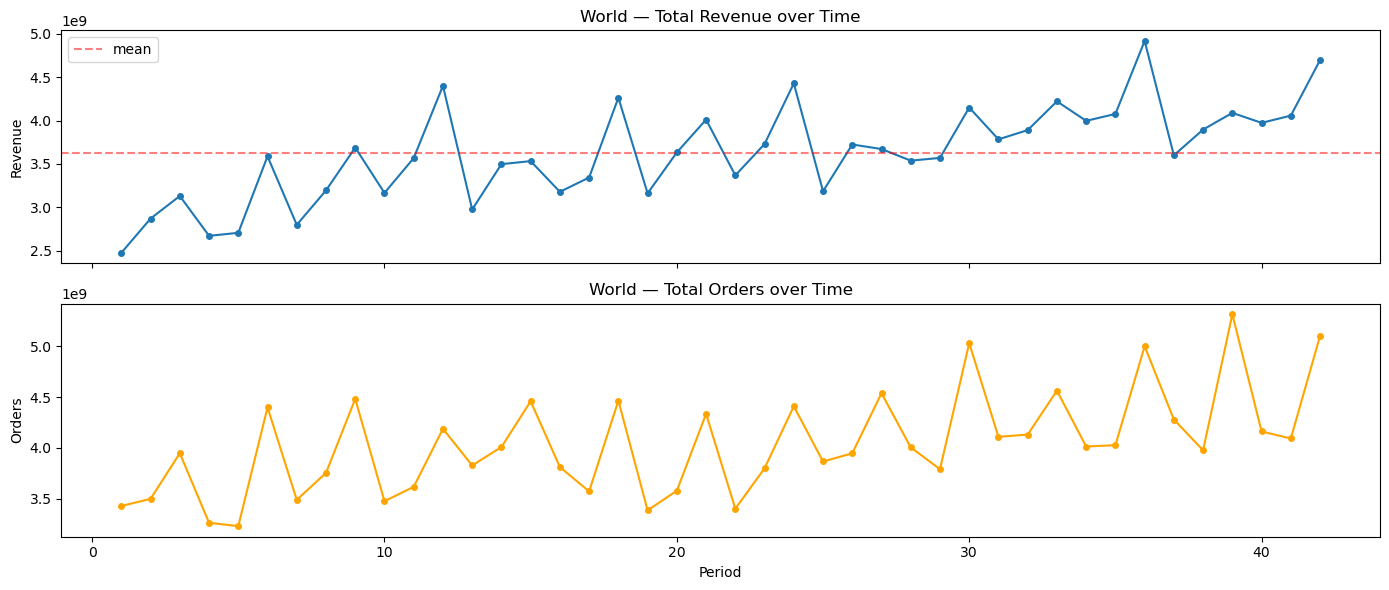

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(world['Period'], world['Revenue'], marker='o', linewidth=1.5, markersize=4)
axes[0].set_title('World — Total Revenue over Time')
axes[0].set_ylabel('Revenue')
axes[0].axhline(world['Revenue'].mean(), color='red', linestyle='--', alpha=0.5, label='mean')
axes[0].legend()

axes[1].plot(world['Period'], world['Orders'], marker='o', linewidth=1.5, markersize=4, color='orange')
axes[1].set_title('World — Total Orders over Time')
axes[1].set_ylabel('Orders')
axes[1].set_xlabel('Period')

plt.tight_layout()
plt.show()

Revenue:

- Clear upward trend overall — the series goes from ~2.5B in early periods to ~4.7B by period 42, meaning the World-level revenue has roughly doubled over the data window. This is important — your models need to capture this trend explicitly.
- The series is not stationary — the mean is visibly drifting upward, which the ADF test will likely confirm. You'll need to either detrend or difference before feeding into certain models.
- There's notable volatility around the trend — big swings up and down between consecutive periods. This suggests either genuine business cyclicality or that some periods aggregate differently (e.g., fiscal quarter-end effects).
- The red mean line sits well below the recent periods, further confirming the trend — the mean is being pulled down by the early low-value periods and is not a good summary statistic for this series.

Orders (orange):

- Much higher and more erratic volatility than Revenue — the swings between consecutive periods are sharper. Orders tend to lead Revenue (a customer places an order before it converts to revenue), so this noisiness is expected.
- There's a possible level shift around period 28–30 where both the mean and variance of Orders seem to increase. Worth flagging as a potential structural break — possibly a business event or COVID recovery effect.
- Orders and Revenue appear to move broadly together but Orders is clearly noisier — this suggests Revenue will be easier to forecast than Orders.

Overall takeaway from this plot: the World level has a clear exploitable trend but significant noise. Seasonality is not yet visible here — you need the STL decomposition to separate it from the trend. Send that one next.

#### 3.1.2 Business unit level

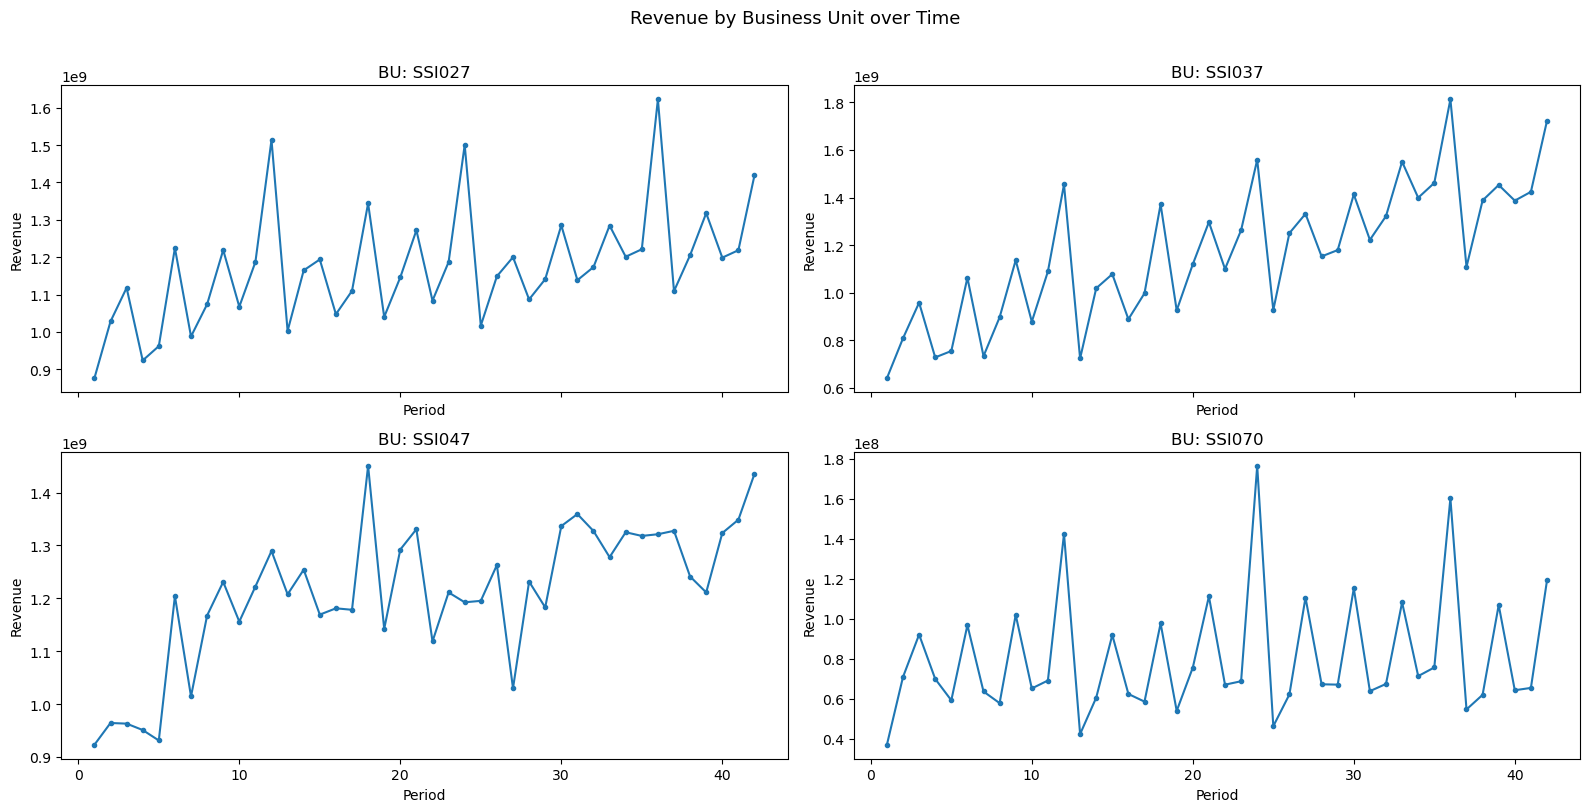

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for i, unit in enumerate(bu['Business_Unit'].unique()):
    data = bu[bu['Business_Unit'] == unit].sort_values('Period')
    axes[i].plot(data['Period'], data['Revenue'], marker='o', linewidth=1.5, markersize=3)
    axes[i].set_title(f'BU: {unit}')
    axes[i].set_ylabel('Revenue')
    axes[i].set_xlabel('Period')

plt.suptitle('Revenue by Business Unit over Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

SSI027:

- Relatively flat trend compared to the other BUs — revenue oscillates mostly between 0.9B and 1.3B with no strong directional drift. The most stable of the four.
- The volatility pattern looks somewhat periodic — there may be a weak seasonal cycle here, but it's hard to confirm without STL.
- The spike around period 25 (~1.6B) stands out as a potential outlier worth investigating.

SSI037:

- The strongest and most consistent upward trend of all four BUs — revenue roughly triples from ~0.6B to ~1.8B over the window. This BU is driving a big part of the World-level trend you saw in the previous plot.
- Despite the trend, there's still meaningful period-to-period volatility, meaning the trend alone won't be enough to forecast this well — you need to capture the residual fluctuations too.

SSI047:

- A moderate upward trend, similar in shape to SSI037 but less steep. Revenue grows from ~0.9B to ~1.4B.
- Notably the smoothest of the four BUs — the swings between consecutive periods are smaller. This is likely your most forecastable BU and potentially a good anchor for the middle-out approach at the BU level.

SSI070:

- Note the y-axis is 1e8, not 1e9 — this BU is an order of magnitude smaller than the others. It contributes very little to World-level totals but will matter for subsegment granularity.
- Very high relative volatility — the swings are large relative to the mean. This is the noisiest and hardest to forecast BU.
- There's a possible slight upward trend but it's completely obscured by the noise.

Cross-BU takeaways relevant to your modeling:

- SSI037 and SSI047 have the clearest structure and should get the most sophisticated models at BU level — Prophet or SARIMA with trend.
- SSI027 is stable and well-suited for ETS or a simpler seasonal model.
- SSI070 is problematic — given its size and noise, errors here won't significantly impact World-level RMSE, but you should flag it. A simple mean or naïve seasonal model may outperform complex ones for this BU.
- The fact that BUs behave so differently from each other confirms that a single global model across all BUs would struggle — fitting separate models per BU is the right call.

#### 3.1.2 Segment level

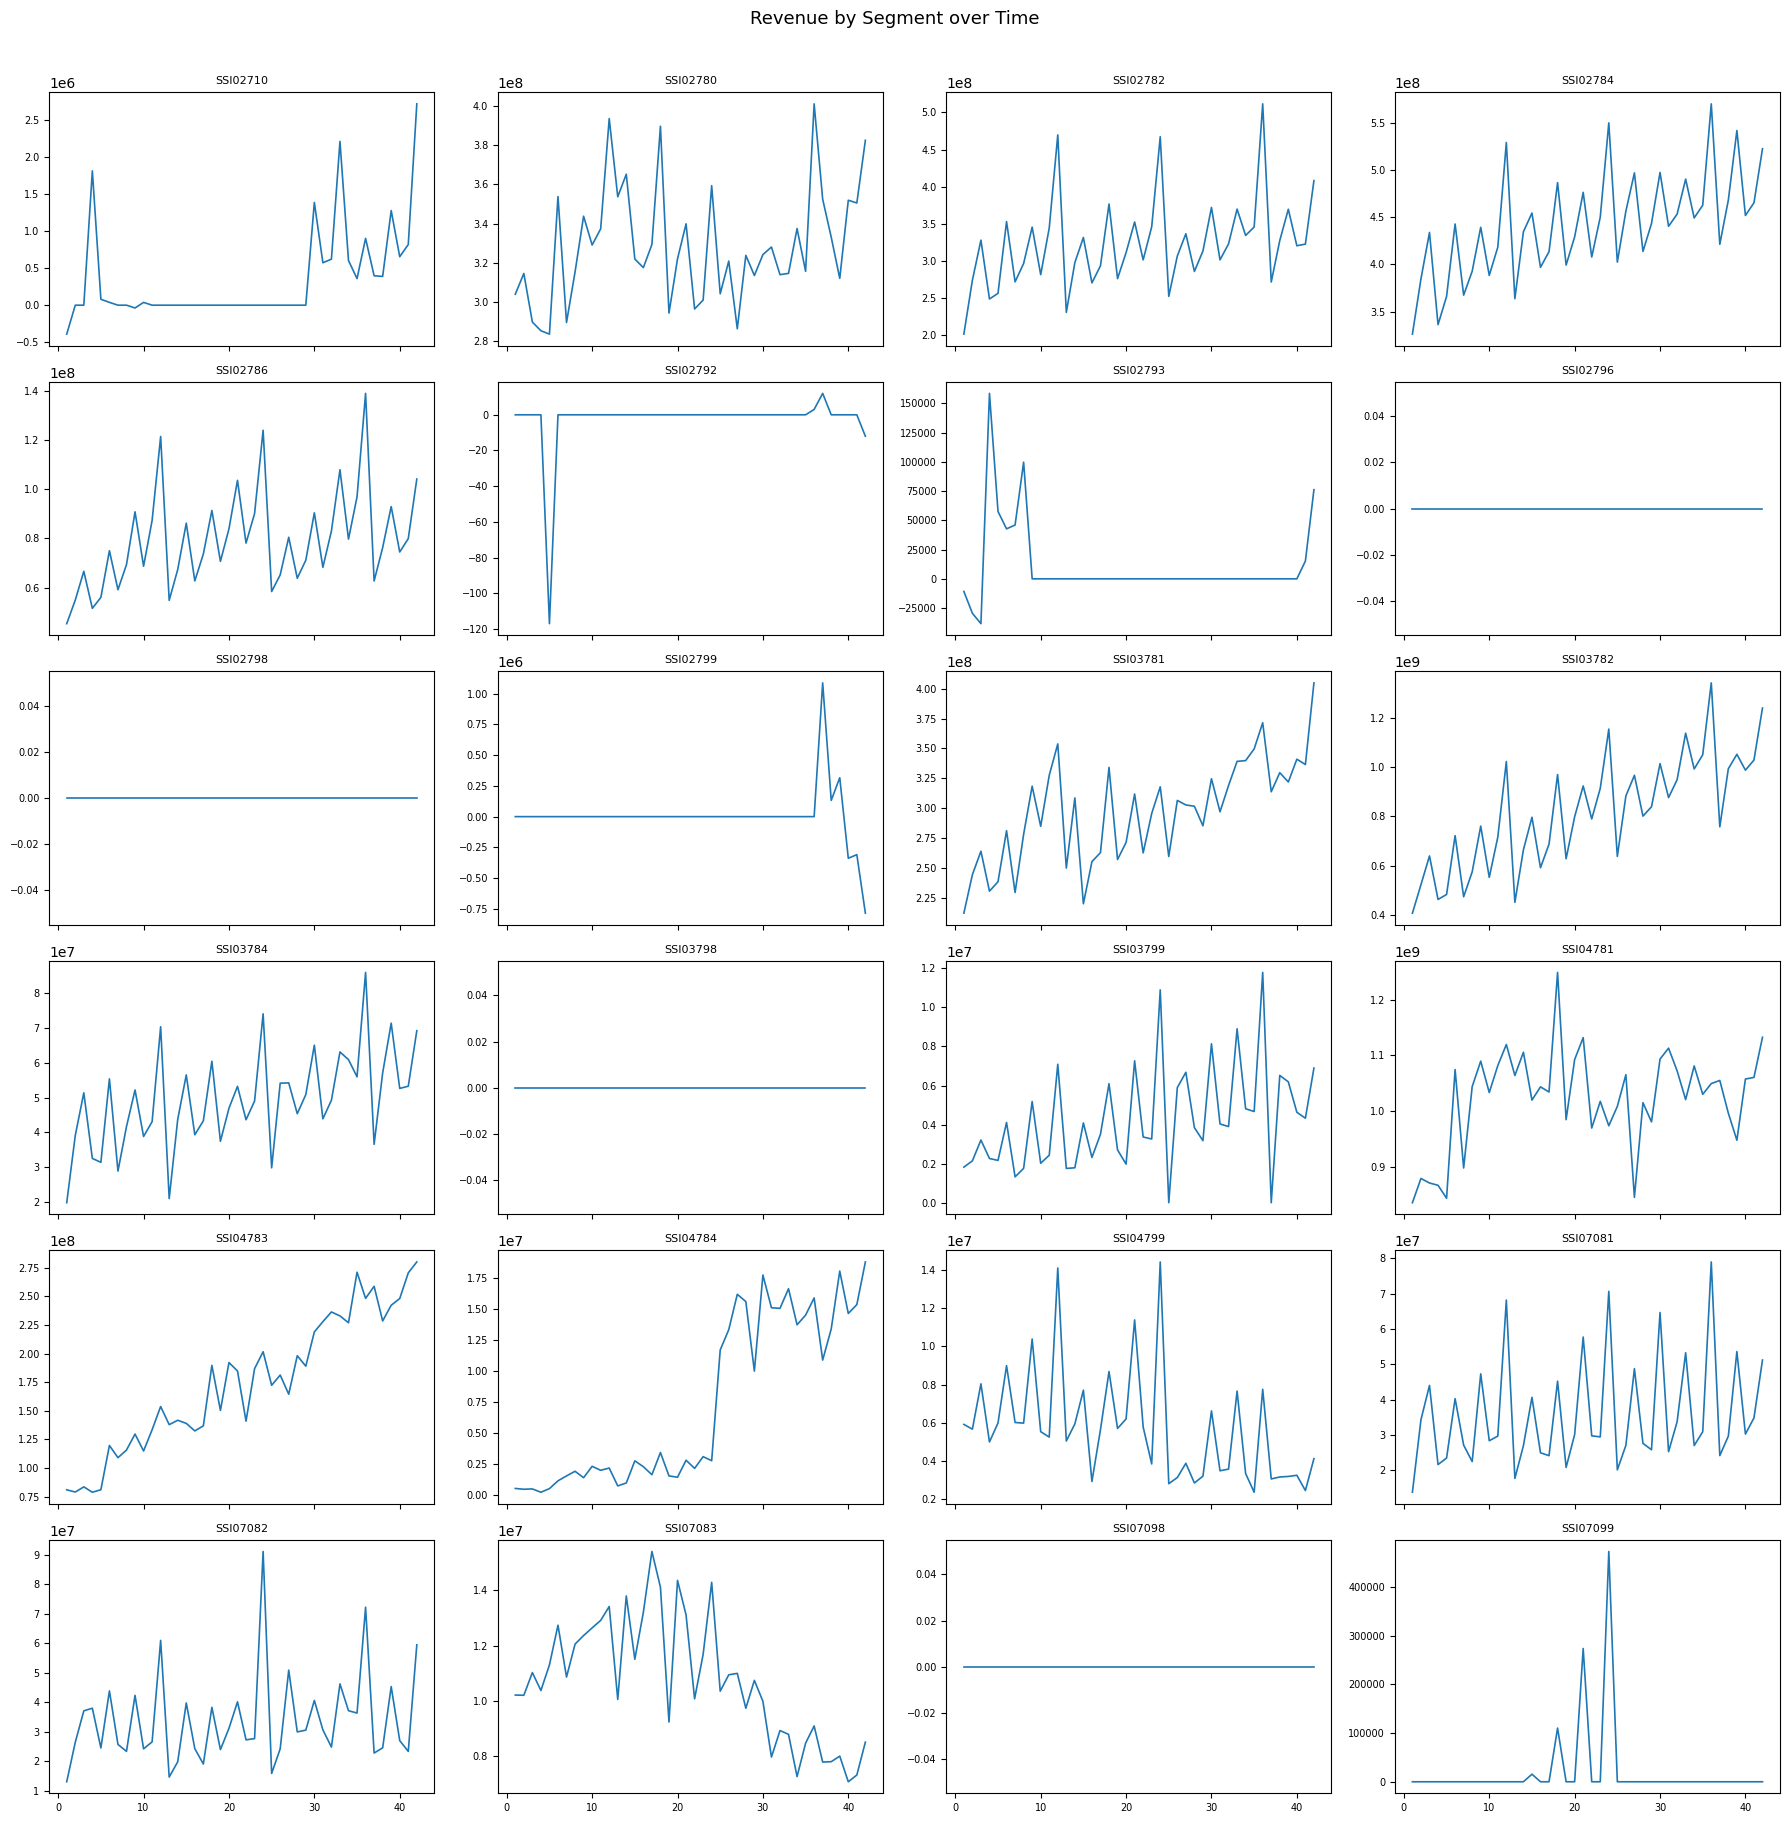

In [13]:
segments = segment['Segment'].unique()
n_cols = 4
n_rows = ceil(len(segments) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3), sharex=True)
axes = axes.flatten()

for i, seg in enumerate(segments):
    data = segment[segment['Segment'] == seg].sort_values('Period')
    axes[i].plot(data['Period'], data['Revenue'], linewidth=1.2)
    axes[i].set_title(seg, fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Revenue by Segment over Time', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Scale heterogeneity is extreme

- Y-axes range from 1e6 to 1e9 across segments — a 1000x difference in magnitude. This means a handful of large segments (SSI03782, SSI04781) will completely dominate any World-level error metric. Small segments could forecast terribly and barely affect your RMSE.

Several segments are essentially flat-zero

- SSI02796, SSI02798, SSI03798, SSI07098 show near-zero values throughout — these are either inactive, discontinued, or placeholder segments. They will cause problems in quota/distribution models (division by near-zero) and should be excluded or handled separately.

Structural breaks are common

- SSI02792 has a massive negative spike early on then flatlines — looks like a one-time accounting correction, not a real revenue pattern.
- SSI02793 has very high early values then drops to near-zero and stays there — a discontinued product line or restructuring event. Modeling this as a continuous series makes no sense.
- SSI02799 and SSI04784 show sudden jumps from zero to active mid-series — new product launches. These series have effectively fewer than 42 usable periods.

Two dominant behavior archetypes

- About half the segments show a clear upward trend with moderate volatility (SSI02784, SSI03781, SSI03782, SSI04781, SSI04783) — these are your well-behaved, forecastable segments and should be your middle-out anchor candidates.
- The other half show high spikiness with no clear trend (SSI02780, SSI02782, SSI02786, SSI03784, SSI07081) — these are harder to model and will likely need simpler approaches like ETS or seasonal naïve.

Seasonality is visible in several segments

- Segments like SSI02784, SSI02786, SSI03781, SSI04783 show fairly regular oscillations on top of their trend — this is promising and suggests STL decomposition will find a usable seasonal component at the segment level.
- The spike-dominated segments (SSI07081, SSI07082) look more like intermittent demand than seasonal patterns — different modeling treatment needed.

Practical implications for your pipeline:

- You likely want to exclude or separately handle the flat-zero and structurally broken segments before fitting any models.
- The middle-out anchor should come from the well-behaved trending segments — they have the richest exploitable structure.
- Consider splitting segments into two groups — "well-behaved" and "problematic" — and applying different model strategies to each rather than one uniform approach.


### 3.2 STL decomposition

#### 3.2.1 World level

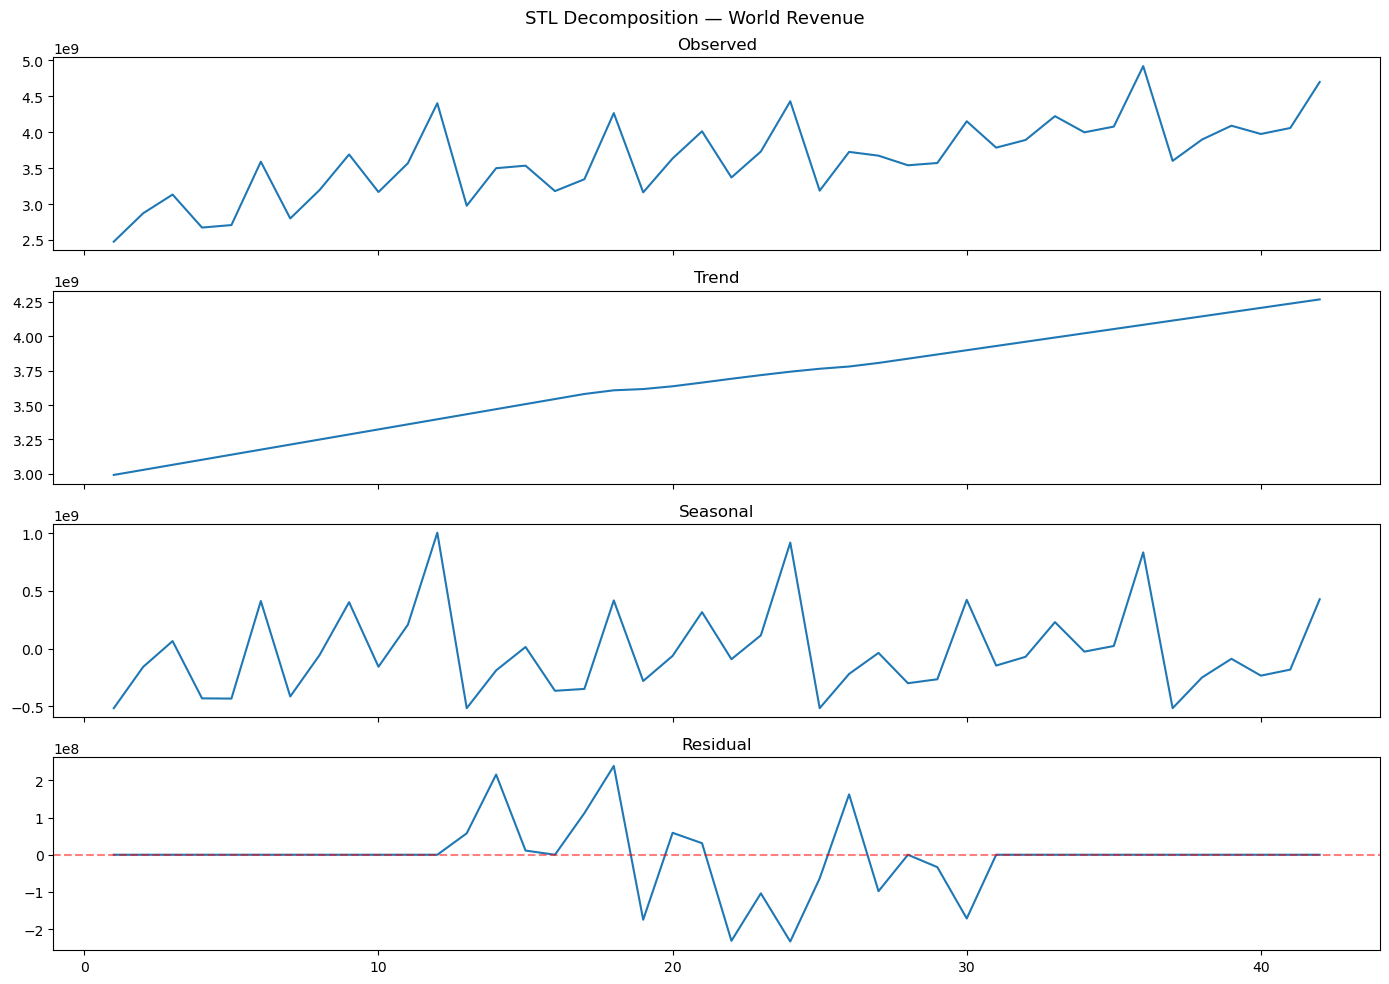

In [14]:
from statsmodels.tsa.seasonal import STL

stl = STL(world['Revenue'], period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(world['Period'], world['Revenue'])
axes[0].set_title('Observed')
axes[1].plot(world['Period'], result.trend)
axes[1].set_title('Trend')
axes[2].plot(world['Period'], result.seasonal)
axes[2].set_title('Seasonal')
axes[3].plot(world['Period'], result.resid)
axes[3].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[3].set_title('Residual')

plt.suptitle('STL Decomposition — World Revenue', fontsize=13)
plt.tight_layout()
plt.show()

Trend

- Almost perfectly linear upward trend from ~3.0B to ~4.3B over the 42 periods. This is the dominant component of the series and your models must capture it — any model that assumes a stationary mean will underperform significantly.
- The linearity is good news — a simple linear trend term or first-differencing will be sufficient. You don't need a complex nonlinear trend model.

Seasonal

- Seasonality is real and strong — the seasonal component oscillates between roughly -0.5B and +1.0B, which is a swing of ~1.5B on a series whose total range is ~2.5B. That means seasonality explains a very large share of the period-to-period variation you saw in the observed plot.
- The pattern is not perfectly regular — some seasonal peaks are much larger than others (e.g., the spike around period 13–14 and again around period 25). This asymmetry suggests the seasonal amplitude may be growing with the trend, which would mean a multiplicative rather than additive seasonality model could fit better. Worth testing both.
- With only ~3.5 full seasonal cycles in 42 periods, the STL is doing its best but the seasonal estimate has uncertainty — don't over-rely on the exact shape.

Residual

- The residuals are on the order of 1e8, while the observed series is 1e9 — so residuals are roughly 10% of the signal. That's reasonably small, meaning the trend + seasonal components together explain ~90% of the variance. Good.
- However the residuals are not pure white noise — there's a cluster of large residuals around periods 15–25, which coincides with what appeared to be higher volatility in the observed plot. This could be a real business event (COVID disruption period) or a sign that the seasonal pattern shifted mid-series.
- The residuals settle down to near-zero after period 30, which is actually encouraging for forecasting — the most recent periods are the cleanest.

Overall STL takeaway for your pipeline:

- Confirmed: trend + seasonality are both worth modeling explicitly — neither can be ignored.
- The World level is well-behaved enough that Prophet (which handles linear trend + Fourier seasonality natively) or Holt-Winters with additive/multiplicative seasonality will work well here.
- The residual cluster in the middle periods is worth flagging — if those correspond to COVID years (roughly 2021–2022 given your date range), you may want to add a dummy regressor for that window to prevent the model from treating it as a seasonal pattern.

#### 3.2.2 Business unit

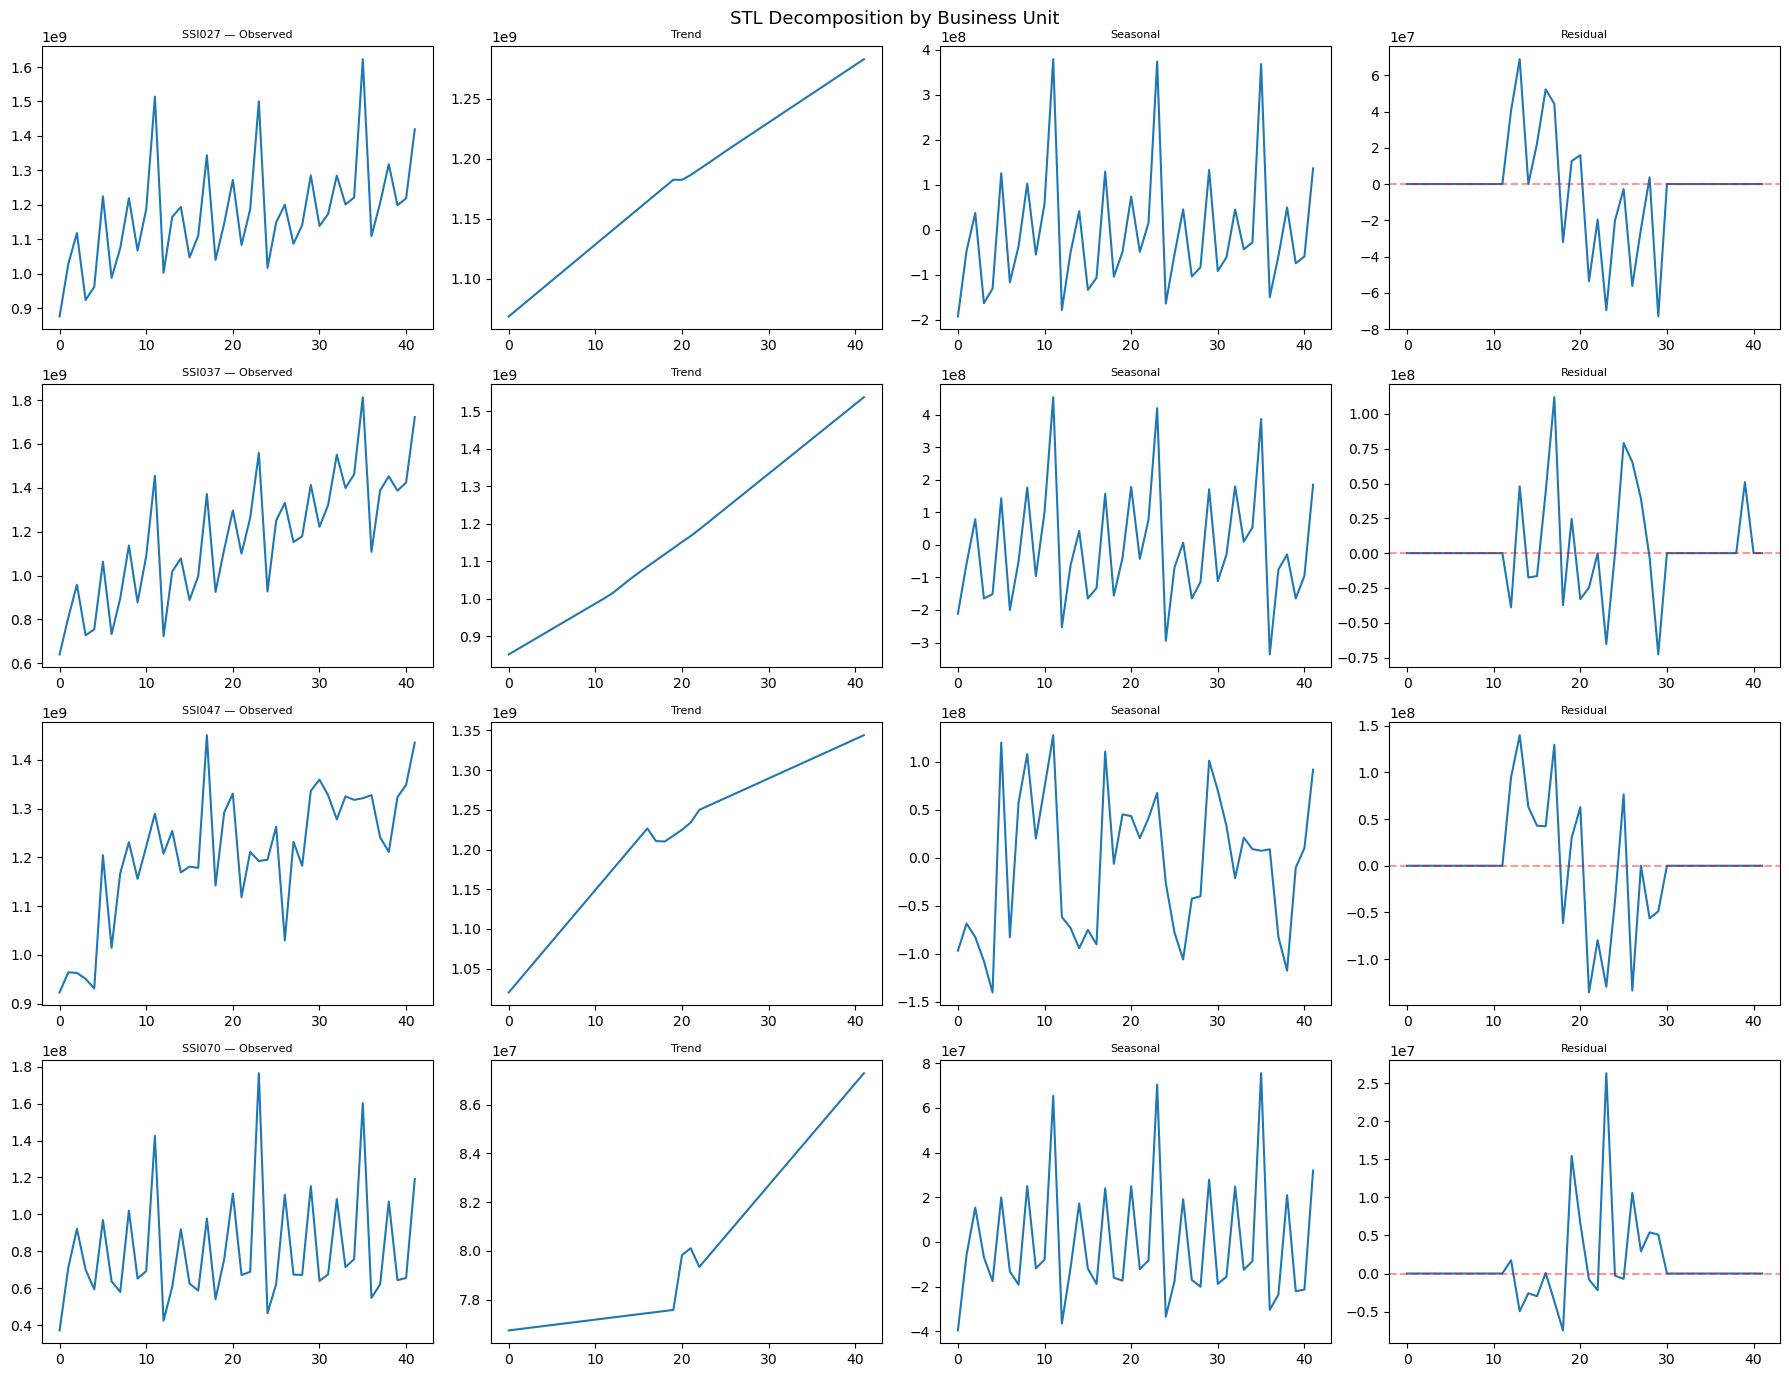

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for i, unit in enumerate(bu['Business_Unit'].unique()):
    data = bu[bu['Business_Unit'] == unit].sort_values('Period')['Revenue']
    stl = STL(data.values, period=12, robust=True)
    res = stl.fit()
    
    axes[i][0].plot(res.observed);  axes[i][0].set_title(f'{unit} — Observed', fontsize=8)
    axes[i][1].plot(res.trend);     axes[i][1].set_title('Trend', fontsize=8)
    axes[i][2].plot(res.seasonal);  axes[i][2].set_title('Seasonal', fontsize=8)
    axes[i][3].plot(res.resid);     axes[i][3].set_title('Residual', fontsize=8)
    axes[i][3].axhline(0, color='red', linestyle='--', alpha=0.4)

plt.suptitle('STL Decomposition by Business Unit', fontsize=13)
plt.tight_layout()
plt.show()

Trend

All 4 BUs show an upward trend, but with very different shapes and steepness.
SSI027 and SSI037 have near-perfectly linear trends — clean and easy to model with a simple linear term or Holt's linear method.
SSI047 has a nonlinear trend — relatively flat until around period 15, then accelerating upward. This is harder to capture and suggests Prophet (which handles changepoints) will outperform SARIMA for this BU specifically.
SSI070 has the most unusual trend — essentially flat until period 20, then a sharp structural jump upward. This is almost certainly a business event (acquisition, restructuring, new market entry) rather than organic growth. Modeling this BU as a single continuous series is questionable — consider using only periods 20–42 as the effective training window for SSI070.

Seasonal

All 4 BUs have a detectable seasonal component, which confirms seasonality is a real feature of the data and not just World-level noise.
SSI027 and SSI037 have the strongest and most consistent seasonal patterns — amplitudes of ~2–4×10⁸, which is significant relative to their total revenue scale. These BUs will benefit the most from explicit seasonal modeling.
SSI047's seasonal component is weaker and less regular, particularly in the first 15 periods where the trend was also flat. The seasonal pattern seems to strengthen as the BU grows — again pointing to multiplicative seasonality.
SSI070 has a visible seasonal pattern but it's hard to trust given the structural break in the trend. The seasonal estimate for periods 0–20 may be contaminated by the level shift.

Residual

SSI027 residuals are small (1e7 scale vs 1e9 observed) — very well decomposed, trend + seasonal explain nearly everything. Best-behaved BU for forecasting.
SSI037 has noticeably larger residuals (1e8 scale) with a cluster of large values in the middle periods — same COVID-era pattern seen at the World level. Add a structural break or dummy regressor for that window.
SSI047 residuals are also large (1e8) and show some persistence — there may be autocorrelation in the residuals that an AR term would help capture.
SSI070 residuals flatten to near-zero after the trend jump, which is a sign that the structural break is dominating everything and the STL is struggling to separate components cleanly.

Modeling implications:

SSI027 → ETS or SARIMA will work well, clean series.
SSI037 → Prophet with a COVID dummy regressor; strong trend + seasonal but noisy middle period.
SSI047 → Prophet with changepoint detection; nonlinear trend needs flexibility.
SSI070 → Either exclude pre-period-20 data, or fit a separate model on the post-break window only. Don't use a standard seasonal model on the full series.
 Sonnet 4.6

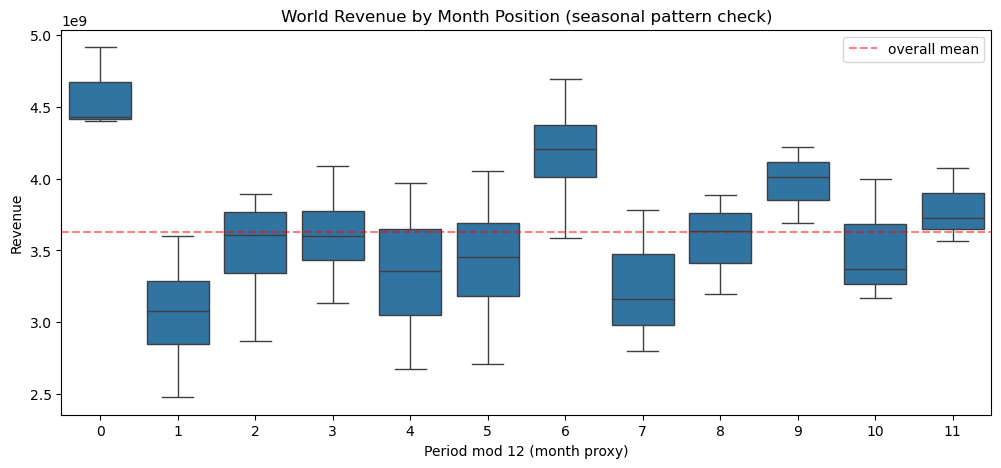

In [16]:
# period mod 12 gives a proxy for month position (0–11)
world['month_pos'] = world['Period'] % 12

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=world, x='month_pos', y='Revenue', ax=ax)
ax.axhline(world['Revenue'].mean(), color='red', linestyle='--', alpha=0.5, label='overall mean')
ax.set_title('World Revenue by Month Position (seasonal pattern check)')
ax.set_xlabel('Period mod 12 (month proxy)')
ax.set_ylabel('Revenue')
ax.legend()
plt.show()

The seasonal pattern that emerges

Position 0 is clearly the highest revenue month — median ~4.6B, well above the overall mean. This corresponds to one specific calendar month that consistently outperforms.
Position 1 is the lowest — median ~3.1B, the furthest below the mean. The drop from position 0 to position 1 is the sharpest transition in the entire cycle.
Position 6 is a secondary peak — median ~4.2B, the second highest position. This suggests a bimodal seasonal pattern with peaks roughly 6 months apart, which is common in B2B industrial sales (two strong booking/delivery cycles per year).
Positions 7 is a secondary trough, mirroring position 1 on the other side of the year.
The overall shape roughly follows: high → low → medium → medium → medium → high → low → medium — a wave with two cycles per year.

The caveat — this is a proxy, not exact months

Because your periods are anonymized and you're using period mod 12 as a month proxy, position 0 may not actually correspond to January. The relative pattern is valid but you cannot label these as specific calendar months without mapping back through the date column you have. You should do that mapping — df_merged.groupby('Period')['Date'].first() will give you the actual calendar month for each period position, which will make this plot interpretable in business terms.

Box widths reveal trend contamination

The boxes at position 0 and 6 are very tight (low variance across the ~3 observations per position) — meaning those peaks are consistent year over year, which is strong evidence of genuine seasonality.
Positions 2–5 and 8–11 have wider boxes — more variance, meaning those middle months are less predictable and more influenced by the underlying trend or random shocks.
This is actually a known artifact of doing this analysis on a trending series — the upward trend means later-year observations of each month position are systematically higher than earlier ones, inflating box width. Ideally you'd detrend first before making this plot, but the pattern is clear enough to trust regardless.

Modeling implications:

The bimodal seasonal pattern with a period-6 secondary peak is important to communicate to your model. A standard annual seasonality assumption (period=12) will capture it, but make sure your seasonal period parameter is set to 12 and not a shorter cycle.
The consistency of the peaks at positions 0 and 6 means these are the most forecastable points in the cycle — your model should nail those. If it doesn't, something is wrong with the seasonal specification.
Since you have the actual Date column, map the positions to real months before finalizing your EDA — knowing whether the peak is September vs December is meaningful for the business stakeholder presentation.

### 3.3 ACF and PACF

#### 3.3.1 World level

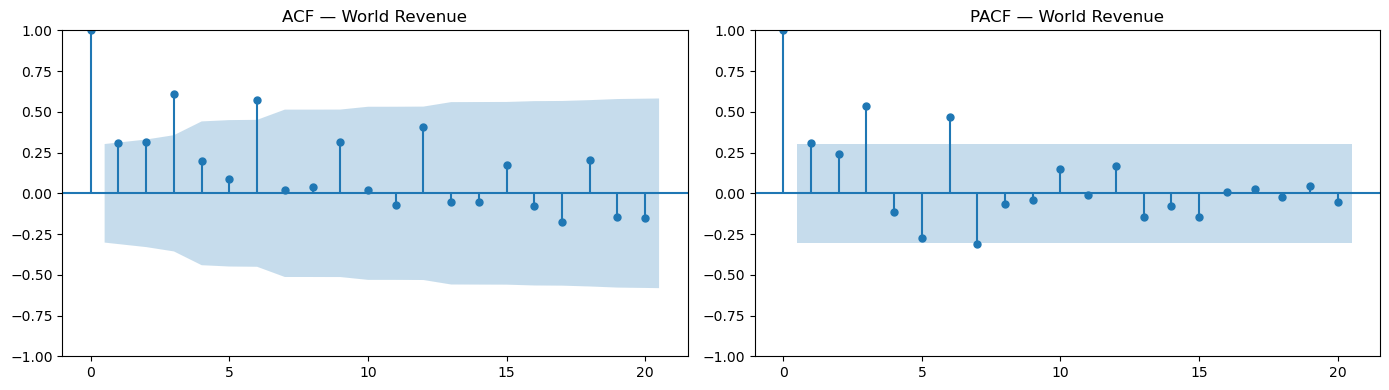

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(world['Revenue'], lags=20, ax=axes[0], title='ACF — World Revenue')
plot_pacf(world['Revenue'], lags=20, ax=axes[1], title='PACF — World Revenue')
plt.tight_layout()
plt.show()

ACF (left)

Lag 1 is significant and positive (~0.30) — the series has meaningful short-term autocorrelation, meaning last period's revenue is a useful predictor of this period's. This is expected and healthy.
Lag 6 spikes strongly (~0.60) and lag 12 spikes again (~0.55) — this is the clearest confirmation yet of the bimodal seasonal pattern you saw in the boxplot. Revenue 6 periods ago and 12 periods ago are strongly correlated with today's value. This is your seasonal signature.
The slow decay of the ACF rather than a sharp cutoff indicates the series is non-stationary — the trend is creating persistent autocorrelation that extends many lags out. This confirms what the STL trend showed — you need to account for the trend before or within your model.
Negative values appearing after lag 13–14 are typical of a series with a strong seasonal cycle — you're seeing the "opposite phase" of the seasonal pattern.

PACF (right)

Significant spikes at lags 1, 2, and 6 — after controlling for intermediate lags, these are the direct predictors.
The spike at lag 6 (~0.48) in the PACF is particularly important — it directly confirms a 6-period seasonal cycle that isn't just inherited from shorter lags.
After lag 6, the PACF drops into the confidence band — meaning lags beyond 6 don't add much direct predictive power once you've accounted for lags 1, 2, and 6.

What this means for model specification:

If using SARIMA, a reasonable starting point is SARIMA(2,1,0)(1,1,0)[6] or (1,1,0)(1,1,0)[12] — the non-seasonal part needs at least AR(2) based on PACF lags 1 and 2, and the seasonal part needs period 6 or 12.
If using Prophet, set seasonality_mode to test both additive and multiplicative, and add a custom 6-period Fourier seasonality on top of the default annual one.
If using LightGBM, include lag features at t-1, t-2, and t-6 as a minimum — those are your three most important lag predictors based on the PACF.
The confidence bands widen significantly at higher lags due to the small sample (42 observations) — treat anything beyond lag 10 with caution, the estimates are unreliable there.

Overall ACF/PACF summary for your pipeline:
The series has AR(2) short-term structure plus a strong seasonal component at period 6 (and harmonically at 12). It is non-stationary in levels. Any model that ignores either the trend or the 6-period seasonality will leave significant predictable variance on the table.

#### 3.3.2 BU

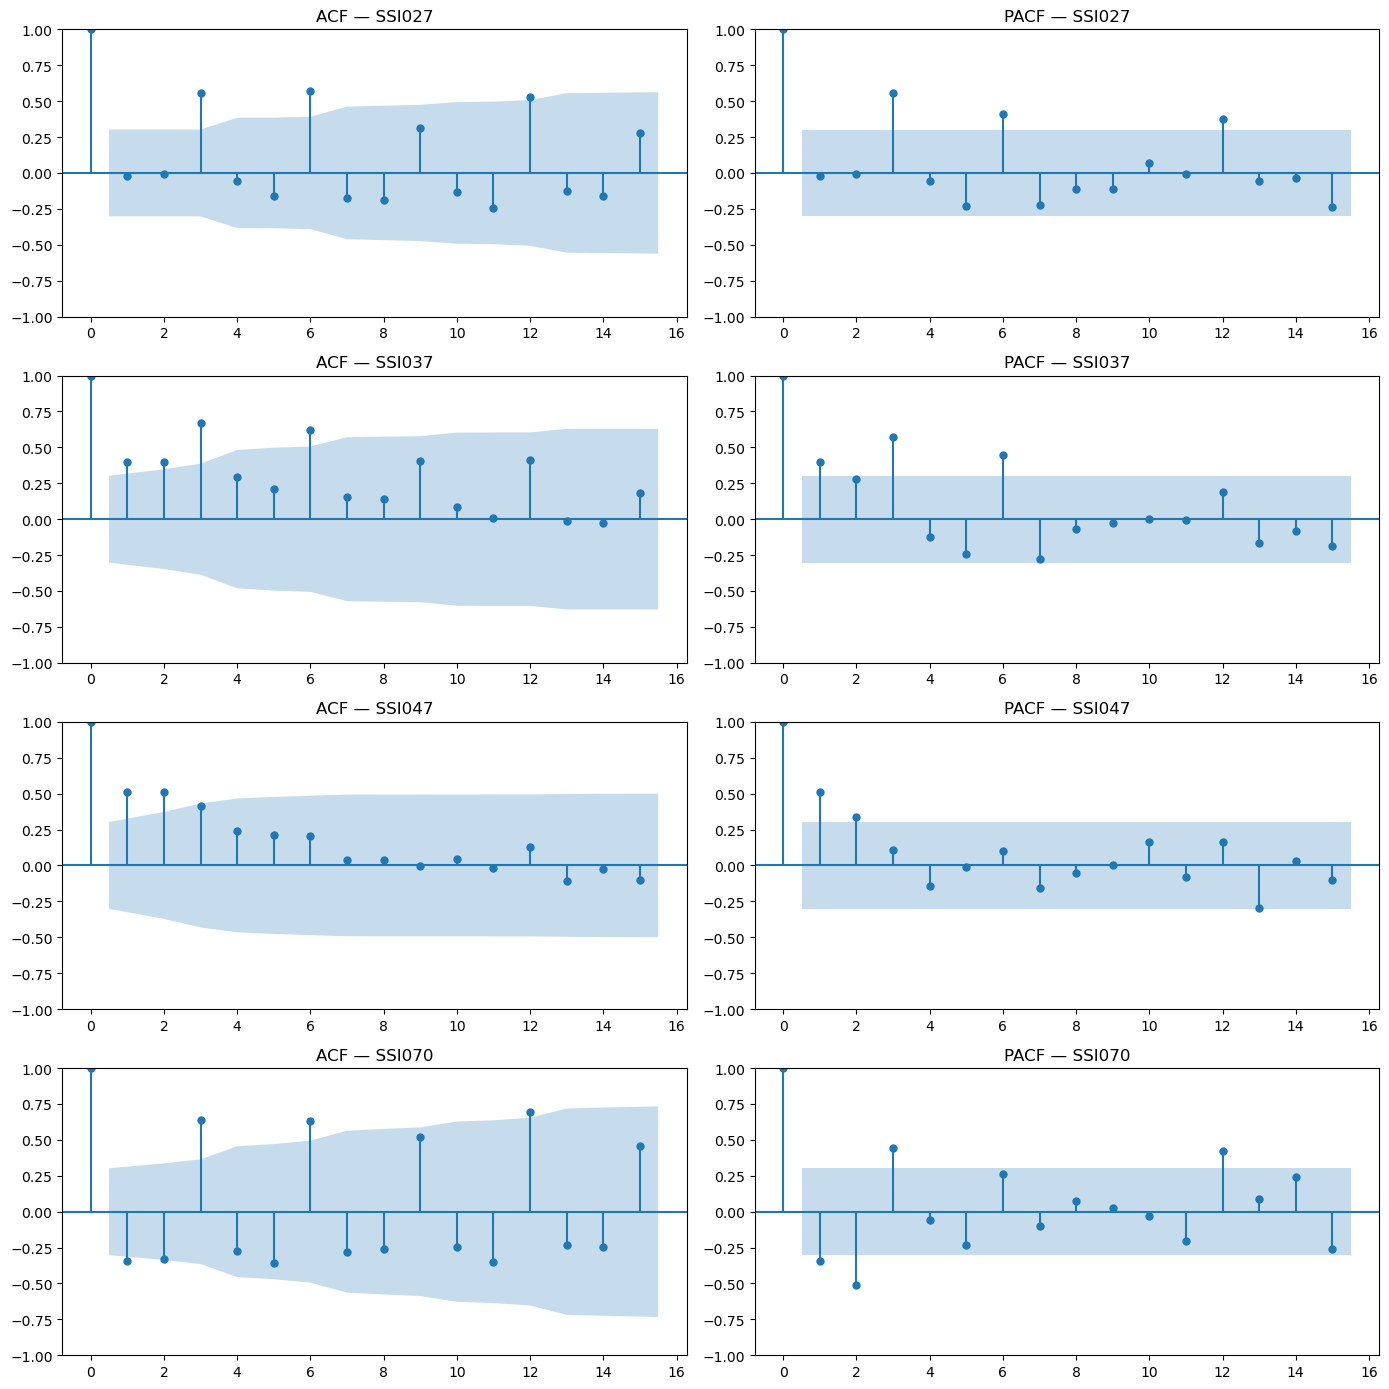

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, unit in enumerate(bu['Business_Unit'].unique()):
    data = bu[bu['Business_Unit'] == unit].sort_values('Period')['Revenue']
    plot_acf(data.values, lags=15, ax=axes[i][0], title=f'ACF — {unit}')
    plot_pacf(data.values, lags=15, ax=axes[i][1], title=f'PACF — {unit}')

plt.tight_layout()
plt.show()

SSI027

ACF shows clear spikes at lags 3, 6, and 12 — the same bimodal seasonal signature as the World level, which makes sense since SSI027 is one of the larger BUs.
PACF has significant spikes at lags 1 and 6 only — simpler AR structure than the World level, suggesting SARIMA(1,1,0)(1,1,0)[6] as a starting point.
Confidence bands are relatively tight — the autocorrelation estimates are reasonably reliable for this BU.

SSI037

ACF decays slowly and remains positive for many lags — classic non-stationary trending series signature, even stronger than what we saw at World level. The trend in SSI037 is so dominant it's bleeding into the autocorrelation structure.
PACF has significant spikes at lags 1, 2, and 6 — similar structure to the World level.
The slow ACF decay is a strong signal to apply first differencing before fitting any ARIMA-type model, or to let Prophet handle the trend natively. Don't fit a stationary model to this series.

SSI047

ACF drops off relatively quickly after lag 1–2 with modest spikes at lags 3 and 6 — the weakest seasonal autocorrelation of all four BUs, consistent with what we saw in the STL where its seasonal component was irregular.
PACF shows only lags 1 and 2 as clearly significant — suggests a simple AR(2) structure after detrending, with only weak seasonality to model.
This BU may actually forecast better with a trend model plus AR(2) residuals than with a full seasonal model.

SSI070

The most unusual pattern — ACF shows strong negative spikes at lags 2 and 8, and positive spikes at lags 3 and 12. This alternating positive/negative pattern in the ACF is a signature of a series that oscillates sharply, which matches the high volatility we saw in its time plot.
PACF has a very large negative spike at lag 2 (~-0.55) which is outside the confidence band — suggesting a MA component rather than pure AR. An ARIMA with a moving average term may fit better for SSI070 than a pure AR model.
Combined with the structural break in its trend, SSI070 remains the most problematic BU. Given all the evidence, seriously consider fitting it on periods 20–42 only and using a simpler model like ETS.

Cross-BU takeaways for modeling:

The lag-6 seasonal spike appears in SSI027 and SSI037 but is weaker in SSI047 and absent as a clean signal in SSI070 — meaning the bimodal seasonality is driven primarily by the two larger BUs and may not be a universal property of the hierarchy.
Fitting a single seasonal period assumption across all BUs would be a mistake — SSI047 and SSI070 need different specifications.
This further reinforces fitting separate models per BU rather than a pooled approach at this level.

### 3.4 Stationary test on all levels

In [7]:
from statsmodels.tsa.stattools import adfuller

print("=== ADF Test Results (p < 0.05 = stationary) ===\n")

print("WORLD:")
p = adfuller(world['Revenue'])[1]
print(f"  Revenue: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}\n")

print("BUSINESS UNITS:")
for unit in bu['Business_Unit'].unique():
    data = bu[bu['Business_Unit'] == unit].sort_values('Period')['Revenue']
    p = adfuller(data)[1]
    print(f"  {unit}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

print("\nSEGMENTS:")
for seg in segment['Segment'].unique():
    data = segment[segment['Segment'] == seg].sort_values('Period')['Revenue']
    if data.nunique() < 2:
        print(f"  {seg}: SKIPPED (constant series)")
        continue
    p = adfuller(data)[1]
    print(f"  {seg}: p = {p:.4f} → {'stationary' if p < 0.05 else 'NON-STATIONARY'}")

=== ADF Test Results (p < 0.05 = stationary) ===

WORLD:
  Revenue: p = 0.6016 → NON-STATIONARY

BUSINESS UNITS:
  SSI027: p = 0.2766 → NON-STATIONARY
  SSI037: p = 0.7132 → NON-STATIONARY
  SSI047: p = 0.0084 → stationary
  SSI070: p = 0.1884 → NON-STATIONARY

SEGMENTS:
  SSI02710: p = 0.9068 → NON-STATIONARY
  SSI02780: p = 0.0189 → stationary
  SSI02782: p = 0.2017 → NON-STATIONARY
  SSI02784: p = 0.3354 → NON-STATIONARY
  SSI02786: p = 0.0270 → stationary
  SSI02792: p = 0.0405 → stationary
  SSI02793: p = 0.0002 → stationary
  SSI02796: SKIPPED (constant series)
  SSI02798: SKIPPED (constant series)
  SSI02799: p = 0.0002 → stationary
  SSI03781: p = 0.9879 → NON-STATIONARY
  SSI03782: p = 0.6993 → NON-STATIONARY
  SSI03784: p = 0.6776 → NON-STATIONARY
  SSI03798: SKIPPED (constant series)
  SSI03799: p = 0.5871 → NON-STATIONARY
  SSI04781: p = 0.0001 → stationary
  SSI04783: p = 0.8978 → NON-STATIONARY
  SSI04784: p = 0.8889 → NON-STATIONARY
  SSI04799: p = 0.6042 → NON-STATIONAR

Overall stationarity summary

The vast majority of series are non-stationary — this is consistent and expected given the upward trends visible throughout the EDA. First differencing or explicit trend modeling is required almost universally.
4 segments were skipped as constant (SSI02796, SSI02798, SSI03798, SSI07098) — these should be formally excluded from your modeling pipeline now.

The "stationary" results need careful interpretation
Not all stationary results mean the same thing. There are three distinct reasons a series passes ADF here:

Genuinely stationary with cyclical behavior — SSI02780, SSI02786, SSI07082 fit this category based on their time plots. These are the noisy, mean-reverting segments you saw earlier. Stationary here is real and meaningful.
Stationary because the series is near-constant or broken — SSI02792, SSI02793, SSI02799 are the structurally broken/near-zero segments. ADF calls a flatline stationary, which is technically correct but useless for forecasting. Treat these separately.
Suspicious stationarity despite visible trend — SSI04781 has p = 0.0001 which is very strongly stationary, yet visually it appeared to have a trend. With only 42 observations ADF can give misleading results, and a structural break mid-series can actually make ADF falsely reject non-stationarity. Always cross-check with the time plot.

Segment groupings for your pipeline
Based on everything from the EDA combined:
Non-stationary trending segments — need differencing or trend modeling: SSI02710, SSI02782, SSI02784, SSI03781, SSI03782, SSI03784, SSI03799, SSI04783, SSI04784, SSI04799, SSI07081, SSI07083, SSI07099
Stationary forecastable segments — can model in levels: SSI02780, SSI02786, SSI07082
Structurally broken / near-zero — handle separately or exclude: SSI02792, SSI02793, SSI02799, SSI02796, SSI02798, SSI03798, SSI07098

### 3.5 Coeffiecient of Variation per level (identify best anchor)

CV — World:       0.152
CV — BU (mean):   0.216
CV — Segment:     5.017
CV — Subsegment:  1.936

→ Lowest CV = richest structure = best middle-out anchor level


C:\Users\nicol\AppData\Local\Temp\ipykernel_13992\3516369612.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cv_summary, x='Level', y='Mean CV', palette='Blues_d')


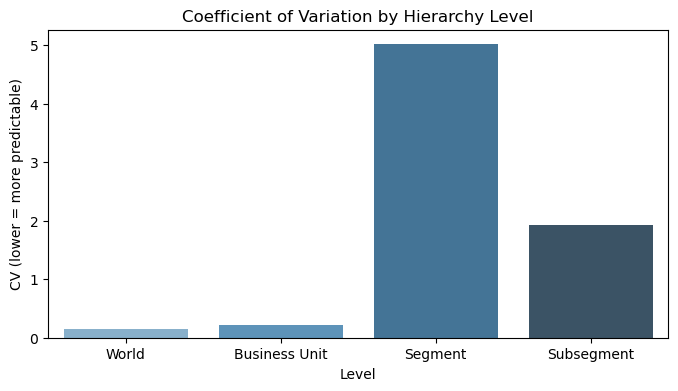

In [20]:
cv_world = world['Revenue'].std() / world['Revenue'].mean()

cv_bu = bu.groupby('Business_Unit')['Revenue'].agg(['std', 'mean'])
cv_bu['CV'] = cv_bu['std'] / cv_bu['mean']

cv_seg = segment.groupby('Segment')['Revenue'].agg(['std', 'mean'])
cv_seg['CV'] = cv_seg['std'] / cv_seg['mean']

cv_subseg = subsegment.groupby('Subsegment')['Revenue'].agg(['std', 'mean'])
cv_subseg['CV'] = cv_subseg['std'] / cv_subseg['mean']

print(f"CV — World:       {cv_world:.3f}")
print(f"CV — BU (mean):   {cv_bu['CV'].mean():.3f}")
print(f"CV — Segment:     {cv_seg['CV'].mean():.3f}")
print(f"CV — Subsegment:  {cv_subseg['CV'].mean():.3f}")
print("\n→ Lowest CV = richest structure = best middle-out anchor level")

# Visual
cv_summary = pd.DataFrame({
    'Level': ['World', 'Business Unit', 'Segment', 'Subsegment'],
    'Mean CV': [cv_world, cv_bu['CV'].mean(), cv_seg['CV'].mean(), cv_subseg['CV'].mean()]
})

plt.figure(figsize=(8, 4))
sns.barplot(data=cv_summary, x='Level', y='Mean CV', palette='Blues_d')
plt.title('Coefficient of Variation by Hierarchy Level')
plt.ylabel('CV (lower = more predictable)')
plt.show()

This is a surprising and very important result. Here's what it tells you:

The pattern is not what you'd typically expect
Normally in a hierarchy you'd see CV increase monotonically as you go down — World lowest, then BU, then Segment, then Subsegment highest. Here the Segment level has a CV of ~5, which is dramatically higher than Subsegment (~2) and completely breaks that expectation.

Why this is happening?
The Segment CV is being inflated by the broken and near-zero segments you identified — SSI02792, SSI02793, SSI02796, SSI02798, SSI02799, SSI03798, SSI07098. These have near-zero means and non-zero standard deviations, which produces astronomically high CV values (std/mean explodes when mean ≈ 0). A handful of these outlier segments are pulling the segment-level mean CV up to 5, which is not representative of the well-behaved segments.

In [9]:
excluded = ['SSI02796', 'SSI02798', 'SSI03798', 'SSI07098', 
            'SSI02792', 'SSI02793', 'SSI02799']

cv_seg_clean = (segment[~segment['Segment'].isin(excluded)]
                .groupby('Segment')['Revenue']
                .agg(['std', 'mean']))
cv_seg_clean['CV'] = cv_seg_clean['std'] / cv_seg_clean['mean'].abs()
print(cv_seg_clean['CV'].mean())

0.6441108056046403


The segment level sits comfortably between BU and subsegment in terms of predictability. It's not as clean as the BU level but it's dramatically more predictable than individual subsegments. This is actually the ideal profile for a middle-out anchor — you want a level that has enough aggregation to be forecastable but enough granularity to make the downward distribution step meaningful.

The honest anchor comparison: 
BU level (CV ~0.20) is more predictable, but you only have 4 series there which gives you very little to work with for the distribution step down to 134 subsegments — that's a very long way to distribute. Segment level (CV ~0.64) gives you ~20 clean series to forecast, and the distribution step down to subsegments is only one level, which keeps the quota model simple and error-contained.

The verdict:
Segment level is confirmed as the right middle-out anchor. The CV evidence supports it, the STL decompositions showed meaningful seasonal structure there, and the one-level distribution step downward is manageable. You can now move forward with confidence in that architectural decision.

### 3.6 Revenue distribution and skew check

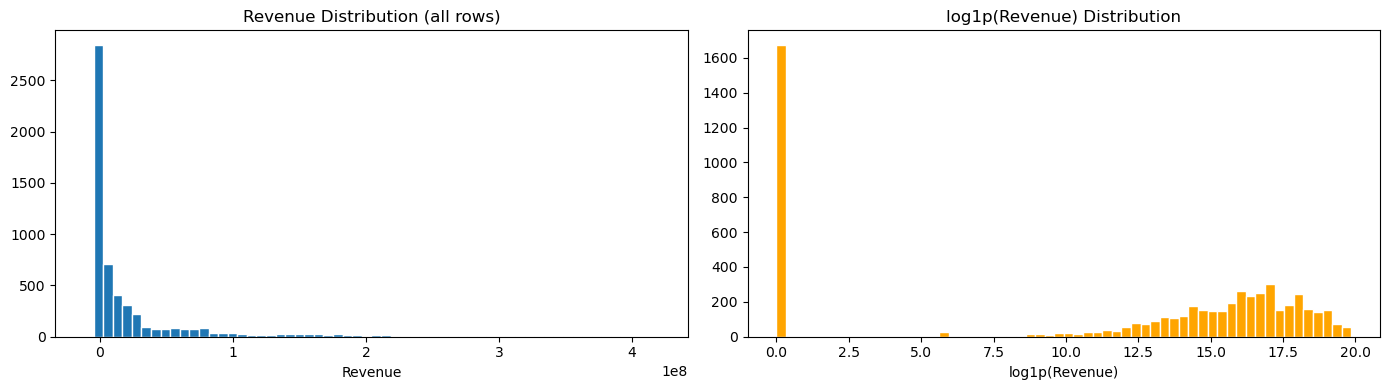

Skewness (raw):     3.258
Skewness (log1p):   -0.663
Negative revenue rows: 33


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_merged['Revenue'], bins=60, edgecolor='white')
axes[0].set_title('Revenue Distribution (all rows)')
axes[0].set_xlabel('Revenue')

axes[1].hist(np.log1p(df_merged['Revenue'].clip(lower=0)), bins=60, edgecolor='white', color='orange')
axes[1].set_title('log1p(Revenue) Distribution')
axes[1].set_xlabel('log1p(Revenue)')

plt.tight_layout()
plt.show()

print(f"Skewness (raw):     {df_merged['Revenue'].skew():.3f}")
print(f"Skewness (log1p):   {np.log1p(df_merged['Revenue'].clip(lower=0)).skew():.3f}")
print(f"Negative revenue rows: {(df_merged['Revenue'] < 0).sum()}")

Raw distribution (left)

- Extremely right-skewed with a massive spike at zero — over 2,800 rows have near-zero revenue. This is the direct consequence of your full grid expansion — all those (period, subsegment) combinations that didn't exist in the original data got filled with zero.
- The actual non-zero revenue values form a long tail stretching to ~4×10⁸, but they're barely visible because the zero spike dominates the chart.
- This distribution is not meaningful to model directly — you can't log-transform, normalize, or fit a standard regression to a distribution that's 50%+ zeros.

Log1p distribution (right)

- The giant bar at 0 on the left confirms the zero-inflation problem visually — roughly 1,600+ rows are true zeros even after log transformation.
- The right portion shows a roughly bell-shaped distribution centered around 15–18 on the log scale, which corresponds to revenues in the range of ~3M to ~65M EUR. This is the healthy part of your data and it looks well-behaved once you separate it from the zeros.
- The gap between 0 and ~5 on the log scale is notable — there are very few small positive values. Revenue is either zero or meaningfully large, which is typical of B2B industrial sales where orders come in lumps.

What this means practically? The zero-inflation is a modeling concern at the subsegment level specifically. When you build your distribution/quota model to disaggregate segment forecasts down to subsegments, dividing by a near-zero mean will cause unstable quotas for the inactive subsegments. The exclusion list you already have (constant series) handles the worst cases, but you should also consider filtering to Period >= Start_Period when computing quotas so you're only using real observations.
For the segment-level models (your middle-out anchor), this is much less of a concern — aggregation removes most of the zeros since at least one subsegment is usually active per segment per period.

In [10]:
real = df_merged[df_merged['Period'] >= df_merged['Start_Period']]
real = real[~real['Segment'].isin(excluded)]

print(f"Zero revenue rows: {(real['Revenue'] == 0).sum()} / {len(real)}")
print(f"Negative revenue rows: {(real['Revenue'] < 0).sum()}")

Zero revenue rows: 272 / 4239
Negative revenue rows: 25


Zero revenue rows (272 / 4239 = 6.4%)

- This is a manageable amount and importantly these are real zeros, not grid-expansion artifacts — these are periods where a subsegment genuinely had no revenue. In B2B industrial sales this is normal — not every product line ships every month.
- 6.4% zero-inflation is low enough that you don't need a specialized zero-inflated model. Standard forecasting models will handle this fine, especially at the segment level where zeros are even rarer due to aggregation.
- When computing quotas for the distribution step, these real zeros are actually informative — they tell you a subsegment was inactive in that period, which is a legitimate signal for the quota model.

Negative revenue rows (25 / 4239 = 0.6%)

- Very small number, good. These are almost certainly credit notes, returns, or accounting corrections rather than genuine negative sales.
- 25 rows is too few to model as a separate process — the simplest and most defensible treatment is to clip them to zero before modeling, since they represent accounting adjustments rather than a real revenue pattern your model should learn.
- Do check whether these negatives are concentrated in specific subsegments or time periods — if they cluster in one or two subsegments it may indicate a data quality issue there specifically.

### 3.7 Cross-series correlation at Segment level (on differenced series)

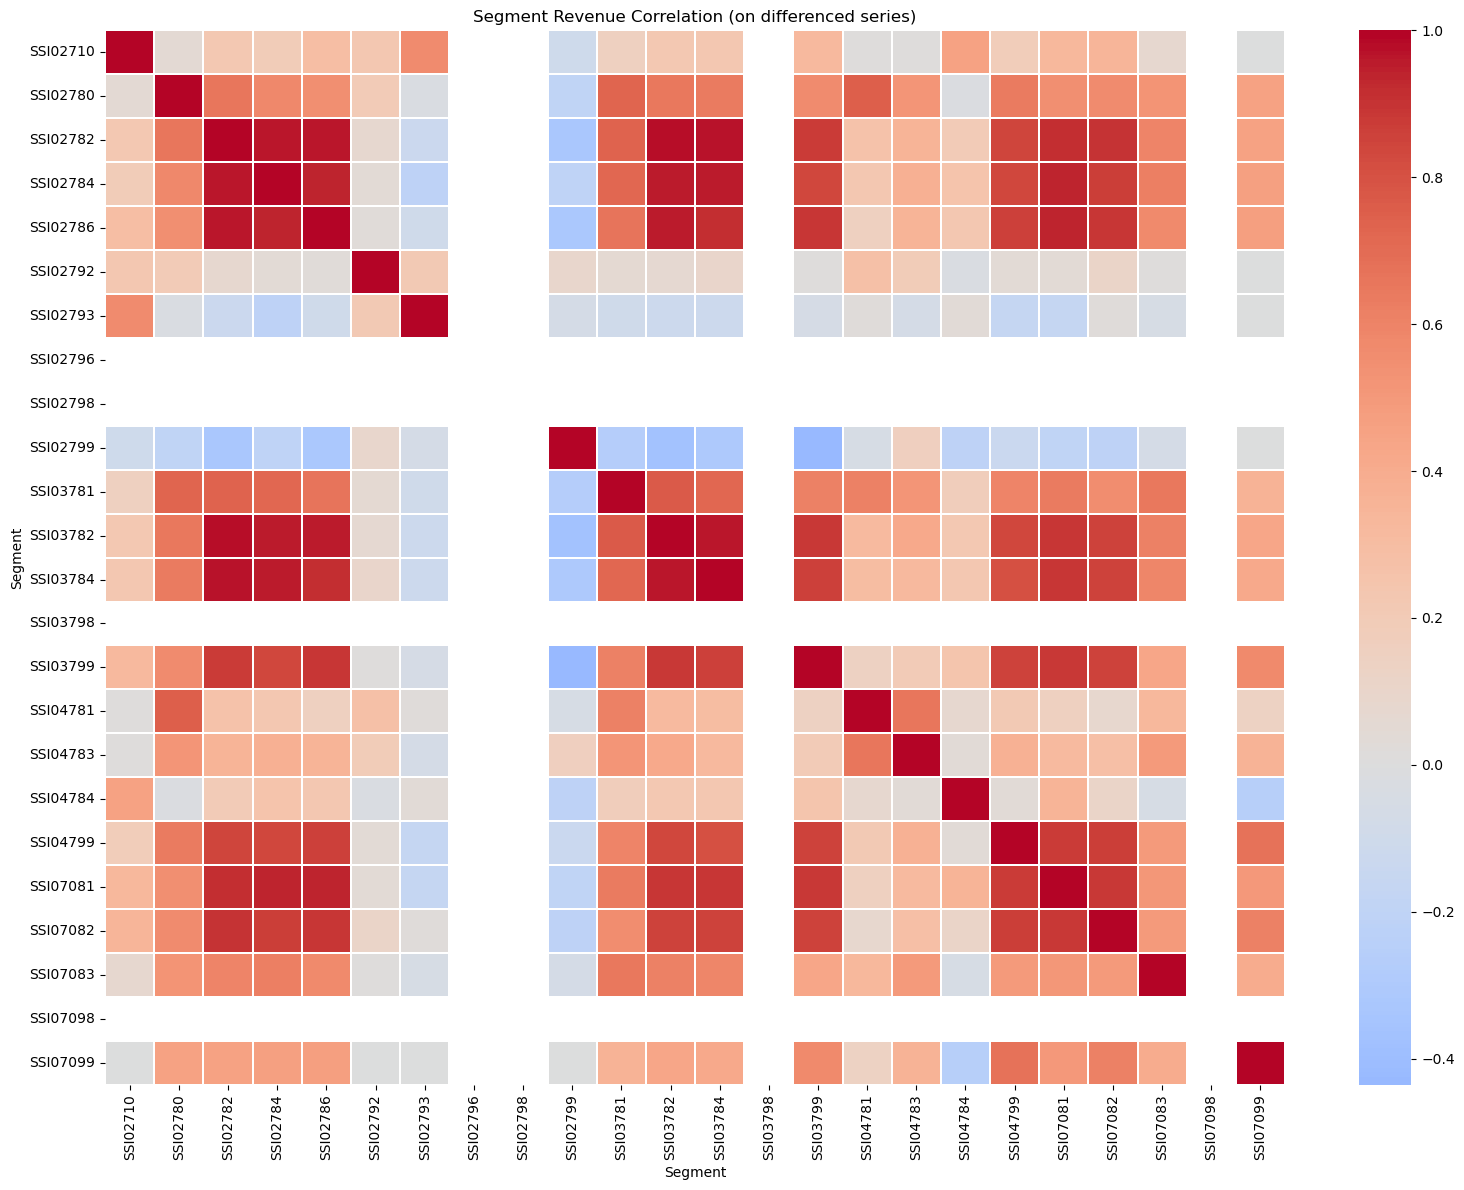

In [22]:
seg_pivot = segment.pivot(index='Period', columns='Segment', values='Revenue')
seg_diff = seg_pivot.diff().dropna()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(seg_diff.corr(), cmap='coolwarm', center=0, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax, annot=False)
ax.set_title('Segment Revenue Correlation (on differenced series)', fontsize=12)
plt.tight_layout()
plt.show()

Within-BU correlations are strong

- The SSI027x block (top-left: SSI02710, SSI02780, SSI02782, SSI02784, SSI02786) shows consistently high positive correlations — these segments move together, likely driven by shared industry demand cycles within that business unit.
- The SSI037x block (SSI03781, SSI03782, SSI03784) is similarly tightly correlated internally.
- The SSI047x block (SSI04781, SSI04783, SSI04784, SSI04799) shows strong internal correlations particularly between SSI04781 and SSI04783.
- SSI070x segments show weaker internal correlation — consistent with what you saw in their noisy time plots and poor STL decomposition.

Cross-BU correlations are mostly weak but not zero

- SSI027x and SSI037x segments show moderate positive correlations with each other — these two BUs appear to share some common macro drivers, possibly because they serve overlapping industrial markets.
- SSI070x is largely uncorrelated with everything else — its near-zero or light colors across the row/column confirm it behaves independently, which further supports treating it differently in your pipeline.

Negative correlations are rare and small

- A few light blue cells appear, mostly involving SSI02793 and SSI02799 — the broken/near-zero segments. Their negative correlations are artifacts of their irregular behavior rather than genuine inverse relationships. Don't read anything into them.
- SSI07099 shows near-zero correlation with almost everything — consistent with it being a late-starting short series with very few real observations.

What this means for your middle-out pipeline

- The strong within-BU correlations confirm that a pooled model per BU (training one LightGBM or similar on all segments within a BU) would be able to exploit these shared patterns — segments within the same BU are not independent and a global model will find that signal.
- The weak cross-BU correlations mean you don't gain much from pooling across BUs — fitting separate models per BU remains the right call.
- For the quota/distribution model, the within-BU correlation structure suggests that when one segment in a BU is up, siblings tend to be up too — meaning quotas are relatively stable rather than shifting dramatically between segments. This is good news for the simplicity of your distribution model.

### 3.8 Macro correlations with World Revenue

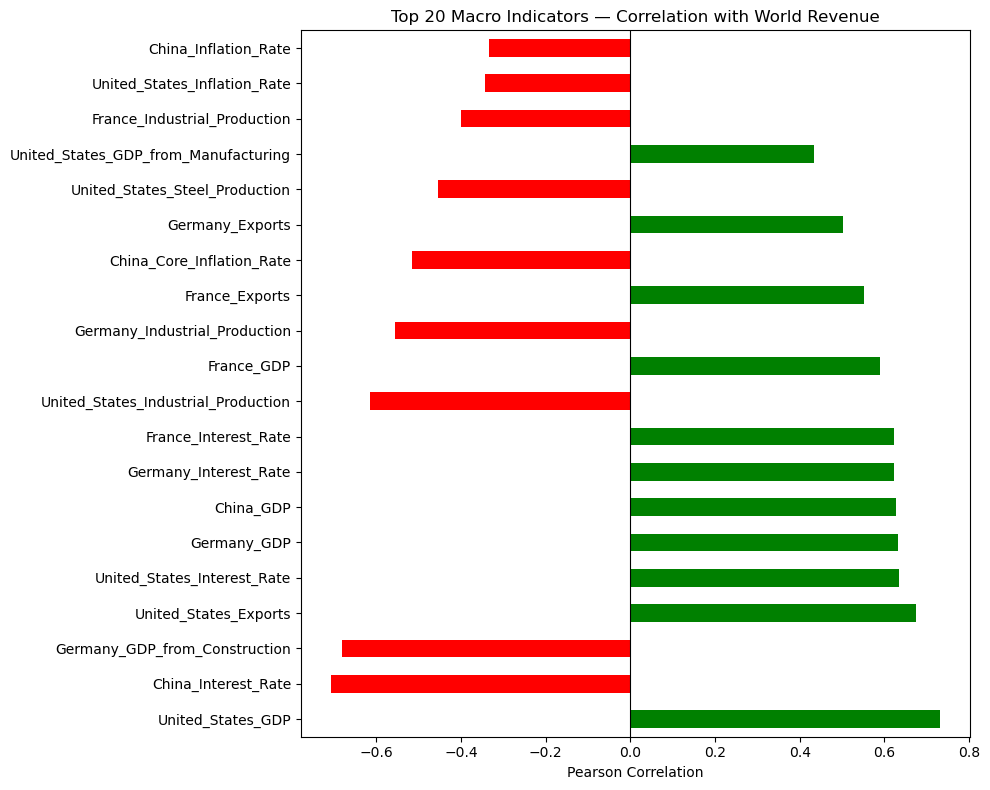

In [23]:
macro_cols = [c for c in df_merged.columns if any(c.startswith(x) for x in 
              ['Germany', 'China', 'United_States', 'France'])]

macro_world = df_merged.groupby('Period')[macro_cols].mean()
macro_world['Revenue'] = world.set_index('Period')['Revenue']

corr_with_revenue = macro_world.corr()['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
corr_with_revenue.head(20).plot(kind='barh', color=['green' if x > 0 else 'red' for x in corr_with_revenue.head(20)])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Macro Indicators — Correlation with World Revenue')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

Strongest positive correlations — include these as priority features

- United_States_GDP (~0.72) and China_GDP (~0.65) are the two strongest predictors — global economic output drives Siemens SI revenue, which makes intuitive sense for an industrial equipment company.
- United_States_Exports (~0.68), United_States_Interest_Rate (~0.65), Germany_Interest_Rate (~0.63), France_Interest_Rate (~0.62) form a tight cluster of strong positives.
- Germany_GDP (~0.63), China_GDP (~0.65), France_GDP (~0.58) — GDP across major economies is consistently positively correlated.
- France_Exports (~0.52) and Germany_Exports (~0.47) are moderately positive.

Strongest negative correlations — also useful as features

- China_Interest_Rate (~-0.72) is the single strongest correlate in either direction — when Chinese interest rates are high, Siemens SI revenue tends to be lower. This likely reflects tighter credit conditions suppressing infrastructure and industrial investment in China.
- Germany_GDP_from_Construction (~-0.65) is counterintuitive — you'd expect construction activity to positively drive infrastructure equipment sales. This may be a lag effect or a spurious correlation driven by the trend; treat with caution.
- United_States_Industrial_Production (~-0.60) being negative is also surprising given Siemens SI's industrial focus. Again possibly a lag effect — industrial production may lead or lag revenue in a non-contemporaneous way.
- Germany_Industrial_Production (~-0.55), France_Industrial_Production (~-0.42), United_States_Steel_Production (~-0.42) are all negatively correlated, which as a group suggests these are leading indicators that move before revenue responds — worth testing with lagged versions (t-1, t-2) rather than contemporaneous values.

The counterintuitive negatives are a warning about spurious correlation
- Remember this is computed on the full differenced series but GDP and interest rate columns were interpolated from quarterly data. Some of these correlations may be partially driven by the shared trend rather than genuine causal relationships. Before using them as features, test with lagged versions and verify the relationship holds on a rolling window.
- Practical feature selection for your models

For your segment-level middle-out models, prioritize these macro features:

- United_States_GDP, China_GDP, Germany_GDP, France_GDP — economic output proxies
United_States_Exports, Germany_Exports, France_Exports — trade activity
China_Interest_Rate, United_States_Interest_Rate — monetary conditions
Test Industrial_Production indicators at t-1 and t-2 lags rather than contemporaneous

Drop or deprioritize indicators with correlations below ~0.35 in absolute value — they add noise without signal given your limited 42-period training window. With ~77 macro features and only 42 observations, aggressive feature selection is essential to avoid overfitting.